# Solution: Drinking Water Demand Forecasting with Recurrent Neural Networks - Part 4
## Probabilistic forecasting with Monte Carlo Dropout

**Probabilistic forecasting** should be preferred to "point forecasts" (e.g., predicting a single value or outcome) as it provides a measure of uncertainty of the predictions.

In this notebook, we will explore how to transform the Recurrent Neural Networks (RNNs) for water demand prediction into probabilistic forecasting models by using **dropout**. Dropout, known for its simplicity and effectiveness, is a form of regularization that randomly deactivates neurons during *training*. This technique prevents the model from becoming overly dependent on specific neurons, promoting a more generalized learning process. Building on this technique, **Monte Carlo Dropout**, where dropout is kept active during *infeerence*, allows the network to generate multiple forecasts by emulating ensembling.

The effectiveness of dropout for regularization or ensembling depends on fine-tuning two key hyperparameters: the *dropout rate* and the specific layers where dropout is applied. These hyperparameters influence the model's performance, balancing the need for regularization with the geeneration of informative prediction intervals.

In probabilistic forecasting, the goal is to achieve prediction intervals that are both accurate in **coverage** and **narrow** in width. This is usually checked on a validation dataset, where the aim is to minimize the intervals width while ensuring most actual values fall within these intervals. These aspects are evaluated using probabilistic metrics like **Prediction Interval Coverage Probability (PICP)** and **Prediction Interval Normalized Average Width (PINAW)**. PICP assesses how well the intervals cover the actual values, while PINAW evaluates the average width of these intervals, giving an indication of their precision.

In summary, dropout in RNNs for probabilistic forecasting offers a powerful combination of simplicity and effectiveness. It not only improves model robustness but also enables the creation of ensemble forecasts for a nuanced understanding of future possibilities. Key to its success is the careful adjustment of dropout rates and application areas, as well as a focused assessment of prediction intervals' coverage and width.

## Walkthrough


### Preliminary steps: load modules and data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import time
import os
from urllib.request import urlretrieve

from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

In [2]:
# Check if CUDA is available, otherwise use CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
# Download the water demand dataset
year_1 = "https://surfdrive.surf.nl/files/index.php/s/hCXnLcb9zlYQHQd/download"
year_2 = "https://surfdrive.surf.nl/files/index.php/s/daXOMuxonOQL1oy/download"

data_folder = "data"
water_demand_file1 = os.path.join(data_folder, "water_demand_Y1.txt")
water_demand_file2 = os.path.join(data_folder, "water_demand_Y2.txt")

if not os.path.isfile(water_demand_file1):
    print("Downloading dataset...")
    os.makedirs("data", exist_ok=True)
    urlretrieve(year_1, water_demand_file1)
    urlretrieve(year_2, water_demand_file2)

In [4]:
# load water demand data
df_year1 = pd.read_csv(water_demand_file1,header=None, sep=r"\s+")
df_year2 = pd.read_csv(water_demand_file2,header=None, sep=r"\s+")
df = pd.concat([df_year1, df_year2], axis = 0).reset_index(drop=True)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,699.9350,740.6850,714.9900,684.2525,597.7575,519.2425,510.1450,614.8825,795.5500,1006.1300,...,1026.0875,918.0225,906.0375,902.1875,922.1850,950.3275,966.3725,877.0875,791.2575,744.4600
1,650.4700,593.2275,539.6425,520.6075,511.2000,500.0075,617.5375,837.5200,987.4875,1081.5075,...,981.8050,908.3025,895.2125,894.2750,976.5050,1016.4225,1057.3275,961.8975,823.3100,775.7425
2,689.5650,610.3225,578.1475,541.6100,521.8300,514.6875,624.4775,838.6775,1012.2075,1105.9875,...,1023.3050,917.2225,905.3750,943.5700,984.5625,1051.1925,1063.4275,953.9950,823.5075,754.7550
3,713.5525,620.6775,569.6550,551.5575,526.7850,518.5625,563.0475,748.1525,965.0550,1149.5875,...,1065.4375,996.6850,988.6625,989.1775,1034.6575,1056.6000,1006.7700,902.1275,804.0650,788.1050
4,723.4175,633.9325,575.2450,545.4650,526.8325,498.9925,523.3400,645.5475,881.3875,1129.3075,...,1070.7375,970.1500,942.8125,933.8925,963.5175,983.4775,988.2550,875.5950,793.1400,761.0325


### Create dataset and data loaders

In [5]:
def create_sequences(series,T=168,H=24):
    # This function creates a dataset of input/output sequences from a time series.
    # The input sequence is T steps long, from time t to time t+T (excluded).
    # The output sequence is H steps long, from time t+T to time t+T+H (excluded).
    X = []
    Y = []
    for t in range(len(series)-T-H):
        x = series[t:t+T]
        X.append(x)
        y = series[t+T:t+T+H]
        Y.append(y)
    X = np.array(X)
    Y = np.array(Y)
    return X,Y

def scale_sequences(X,scaler=None,scaler_type='standard'):
    # Uses a standard scaler to transform sequences. The scaler is created if no scaler is passed as argument.
    Xshape=X.shape
    if scaler:
        X = scaler.transform(X.reshape(-1,1)).reshape(Xshape)
        return X
    else:
        if scaler_type == 'standard':
            scaler = StandardScaler()
        elif scaler_type == 'minmax':
            scaler = MinMaxScaler()
        else:
            raise Exception("Type of scikit-learn scaler not supported. Choose 'standard' or 'minmax.")
        X = scaler.fit_transform(X.reshape(-1,1)).reshape(Xshape)
        return X, scaler

In [6]:
T = 168     # number of time steps to use for prediction (168 hours = 1 week)
H = 24      # number of time steps to predict (1 day)
X, Y = create_sequences(df.values.reshape(-1),T=T,H=H)
print(X.shape)
print(Y.shape)

(17328, 168)
(17328, 24)


In [7]:
# We keep track of indexes of train and validation.
X_tra, X_tst, Y_tra, Y_tst, ix_tra, ix_tst = train_test_split(
    X, Y, np.arange(X.shape[0]), test_size=0.30, shuffle=True, random_state=42)

# Split the existing test dataset into validation and test sets (50/50 split)
X_val, X_tst, Y_val, Y_tst, ix_val, ix_tst = train_test_split(
    X_tst, Y_tst, ix_tst, test_size=0.5, shuffle=True, random_state=42)


print(f"X_tra.shape: {X_tra.shape}, Y_tra.shape: {Y_tra.shape}")
print(f"X_val.shape: {X_val.shape}, Y_val.shape: {Y_val.shape}")
print(f"X_tst.shape: {X_tst.shape}, Y_tst.shape: {Y_tst.shape}")

X_tra.shape: (12129, 168), Y_tra.shape: (12129, 24)
X_val.shape: (2599, 168), Y_val.shape: (2599, 24)
X_tst.shape: (2600, 168), Y_tst.shape: (2600, 24)


In [8]:
# scale/normalize
X_tra, scaler = scale_sequences(X_tra, scaler_type='standard')
Y_tra = scale_sequences(Y_tra, scaler)
X_val = scale_sequences(X_val, scaler)
Y_val = scale_sequences(Y_val, scaler)
X_tst = scale_sequences(X_tst, scaler)
Y_tst = scale_sequences(Y_tst, scaler)

In [9]:
train_dataset = TensorDataset(torch.tensor(X_tra, dtype=torch.float32), torch.tensor(Y_tra, dtype=torch.float32))
val_dataset = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(Y_val, dtype=torch.float32))
test_dataset = TensorDataset(torch.tensor(X_tst, dtype=torch.float32), torch.tensor(Y_tst, dtype=torch.float32 ))

batch_size = 256      # You can modify this based on your requirements

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

### GatedRNN class and training functions

In [10]:
class GatedRNN(nn.Module):
    def __init__(self, hidden_size, output_size, rnn_type='LSTM', dropout_rate = 0):
        super(GatedRNN, self).__init__()

        # Check the rnn_type and initialize the appropriate RNN layer (GRU or LSTM)
        if rnn_type == 'GRU':
            self.rnn = nn.GRU(input_size=1, hidden_size=hidden_size, batch_first=True)
        elif rnn_type == 'LSTM':
            self.rnn = nn.LSTM(input_size=1, hidden_size=hidden_size, batch_first=True)
        else:
            raise ValueError("Invalid RNN type. Choose 'GRU' or 'LSTM'")

        # Output layer
        self.dropout = nn.Dropout(p = dropout_rate)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Reshape input to have feature dimension of 1
        x = x.unsqueeze(-1)   # Assuming input x has shape (batch, sequence)

        # RNN layer
        x, _ = self.rnn(x)   # We do not need the hidden states

        # Select the output of the last time step
        x = x[:, -1, :]

        # Output layer
        x = self.dropout(x)
        x = self.fc(x)

        return x

In [11]:
def evaluate_model(model, test_loader, criterion, device):
    model.eval()  # Set the model to evaluation mode
    test_loss = 0

    with torch.no_grad():  # No need to track gradients during evaluation
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            test_loss += loss.item()

    avg_test_loss = test_loss / len(test_loader)
    return avg_test_loss

def train_and_validate(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, save_path, echo_iter = 20):
    best_val_loss = float("inf")  # Track the best validation loss
    train_losses = []
    val_losses = []

    start_time = time.time()  # Start training time

    for epoch in range(num_epochs):
        # Training Phase
        model.train()
        total_train_loss = 0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation Phase
        avg_val_loss = evaluate_model(model, val_loader, criterion, device)
        val_losses.append(avg_val_loss)

        # Save Best Model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), save_path)

        if echo_iter > 0:
            if (epoch + 1) % echo_iter == 0:
                print(f'Epoch {epoch+1}/{num_epochs}', f'Train Loss: {avg_train_loss:.4f}, '
                      f'Validation Loss: {avg_val_loss:.4f}', f'Best Validation Loss: {best_val_loss:.4f}')

    train_time = time.time() - start_time
    if echo_iter > 0:
        print("Training complete.")
    return train_losses, val_losses, best_val_loss, train_time

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

### Train and test GatedRNN with Dropout

In [12]:
!mkdir models

In [13]:
# train GatedRNN model with dropout
model_24hours_dropout = GatedRNN(128,24,'LSTM',dropout_rate = 0.2).to(device)
save_path = f'./models/model_24hours_dropout.pth'

In [14]:
lr = 0.001
criterion = nn.MSELoss()
optimizer = optim.AdamW(model_24hours_dropout.parameters(), lr=lr)
num_epochs = 1000
train_losses, val_losses, _, elapsed_time = train_and_validate(model_24hours_dropout, train_loader, val_loader,
                                                               criterion, optimizer, num_epochs, device, save_path, echo_iter = 100)

Epoch 100/1000 Train Loss: 0.0657, Validation Loss: 0.0490 Best Validation Loss: 0.0485
Epoch 200/1000 Train Loss: 0.0557, Validation Loss: 0.0351 Best Validation Loss: 0.0346
Epoch 300/1000 Train Loss: 0.0459, Validation Loss: 0.0270 Best Validation Loss: 0.0270
Epoch 400/1000 Train Loss: 0.0407, Validation Loss: 0.0225 Best Validation Loss: 0.0225
Epoch 500/1000 Train Loss: 0.0370, Validation Loss: 0.0191 Best Validation Loss: 0.0191
Epoch 600/1000 Train Loss: 0.0349, Validation Loss: 0.0170 Best Validation Loss: 0.0160
Epoch 700/1000 Train Loss: 0.0332, Validation Loss: 0.0155 Best Validation Loss: 0.0149
Epoch 800/1000 Train Loss: 0.0319, Validation Loss: 0.0139 Best Validation Loss: 0.0137
Epoch 900/1000 Train Loss: 0.0311, Validation Loss: 0.0133 Best Validation Loss: 0.0127
Epoch 1000/1000 Train Loss: 0.0307, Validation Loss: 0.0130 Best Validation Loss: 0.0122
Training complete.


In [15]:
# load best weights
model_24hours_dropout.load_state_dict(torch.load(save_path, map_location=torch.device(device)))

criterion = nn.MSELoss()  # Or another appropriate loss function
avg_test_loss = evaluate_model(model_24hours_dropout, test_loader, criterion, device)
print(f"GatedRNN --> num. trainable parameters:{count_parameters(model_24hours_dropout):8d} | Test loss: {avg_test_loss:.4f}")

GatedRNN --> num. trainable parameters:   70168 | Test loss: 0.0120


<ipython-input-15-a32ac4e932bb>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_24hours_dropout.load_state_dict(torch.load(save_path, map_location=torch.device(device

###  Compute and visualize Monte Carlo dropout prediction intervals

#### Define functions for computation of prediction intervals and probabilistic metrics

In [16]:
def generate_dropout_predictions(model, input_data, num_samples=30):
    model.train()  # Enable dropout
    with torch.no_grad():  # Disable gradient calculations
        predictions = [model(input_data) for _ in range(num_samples)]
    return torch.stack(predictions, dim=0)

In [17]:
def calculate_prediction_intervals(predictions, percentile=95):
    """
    Calculate prediction intervals from multiple predictions.

    Parameters:
    - predictions: Array of predictions.
    - percentile: The confidence level for the interval.

    Returns:
    - lower_bound: Lower bounds of prediction intervals.
    - upper_bound: Upper bounds of prediction intervals.
    """
    lower_percentile = (100 - percentile) / 2
    upper_percentile = 100 - lower_percentile

    lower_bound = torch.quantile(predictions, lower_percentile / 100, dim=0)
    upper_bound = torch.quantile(predictions, upper_percentile / 100, dim=0)

    return lower_bound, upper_bound


def calculate_picp(y_true, lower_bound, upper_bound):
    """
    Calculate the Prediction Interval Coverage Probability (PICP).

    Parameters:
    - y_true: Actual values.
    - lower_bound: Lower bound of the prediction intervals.
    - upper_bound: Upper bound of the prediction intervals.

    Returns:
    - PICP value.
    """
    coverage = torch.where((y_true >= lower_bound) & (y_true <= upper_bound), 1, 0)
    picp = torch.mean(coverage, dtype=float)
    return picp * 100

def calculate_pinaw(y_true, lower_bound, upper_bound, epsilon=1e-8):
    """
    Calculate the Prediction Interval Normalized Average Width (PINAW)
    normalized by the range of y_true.

    Parameters:
    - y_true: Actual values (Tensor).
    - lower_bound: Lower bound of the prediction intervals (Tensor).
    - upper_bound: Upper bound of the prediction intervals (Tensor).
    - epsilon: Small value to avoid division by zero (default: 1e-8).

    Returns:
    - PINAW value (float).
    """
    # Calculate interval width
    interval_width = upper_bound - lower_bound  # Shape: [N]

    # Calculate the range of y_true
    data_range = torch.max(y_true) - torch.min(y_true)

    # Add small epsilon for stability in case the range is 0
    normalized_width = interval_width / (data_range + epsilon)  # Normalized width

    # Mean of normalized widths
    pinaw = torch.mean(normalized_width)
    return pinaw

In [18]:
def compute_picp_pinaw_loader(model, loader, percentile = 95, num_samples=30):
    all_picps  = []
    all_pinaws = []

    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        predictions = generate_dropout_predictions(model, inputs, num_samples=num_samples)

        # Compute upper and lower bound of prediction intervals
        lb, ub = calculate_prediction_intervals(predictions, percentile)

        # Compute metrics
        picp = calculate_picp(targets, lb, ub)
        pinaw = calculate_pinaw(targets, lb, ub)

        all_picps.append(picp.cpu().numpy())
        all_pinaws.append(pinaw.cpu().numpy())

    return np.array(all_picps).mean(), np.array(all_pinaws).mean()

#### Compute average metrics for all datasets

In [19]:
# Return average metrics (95% percentile) for training, validation and test
tra_picp, tra_pinaw = compute_picp_pinaw_loader(model_24hours_dropout, train_loader, percentile=95, num_samples=100)
val_picp, val_pinaw = compute_picp_pinaw_loader(model_24hours_dropout, val_loader, percentile=95, num_samples=100)
tst_picp, tst_pinaw = compute_picp_pinaw_loader(model_24hours_dropout, test_loader, percentile=95, num_samples=100)

print(f"Training dataset:\t PICP={tra_picp:.2f}% pinaw={tra_pinaw:.4f}")
print(f"Validation dataset:\t PICP={val_picp:.2f}% pinaw={val_pinaw:.4f}")
print(f"Test dataset:\t\t PICP={tst_picp:.2f}% pinaw={tst_pinaw:.4f}")

Training dataset:	 PICP=97.36% pinaw=0.1027
Validation dataset:	 PICP=96.74% pinaw=0.1037
Test dataset:		 PICP=96.82% pinaw=0.1044


#### Visualize individual prediction intervals for the test dataset

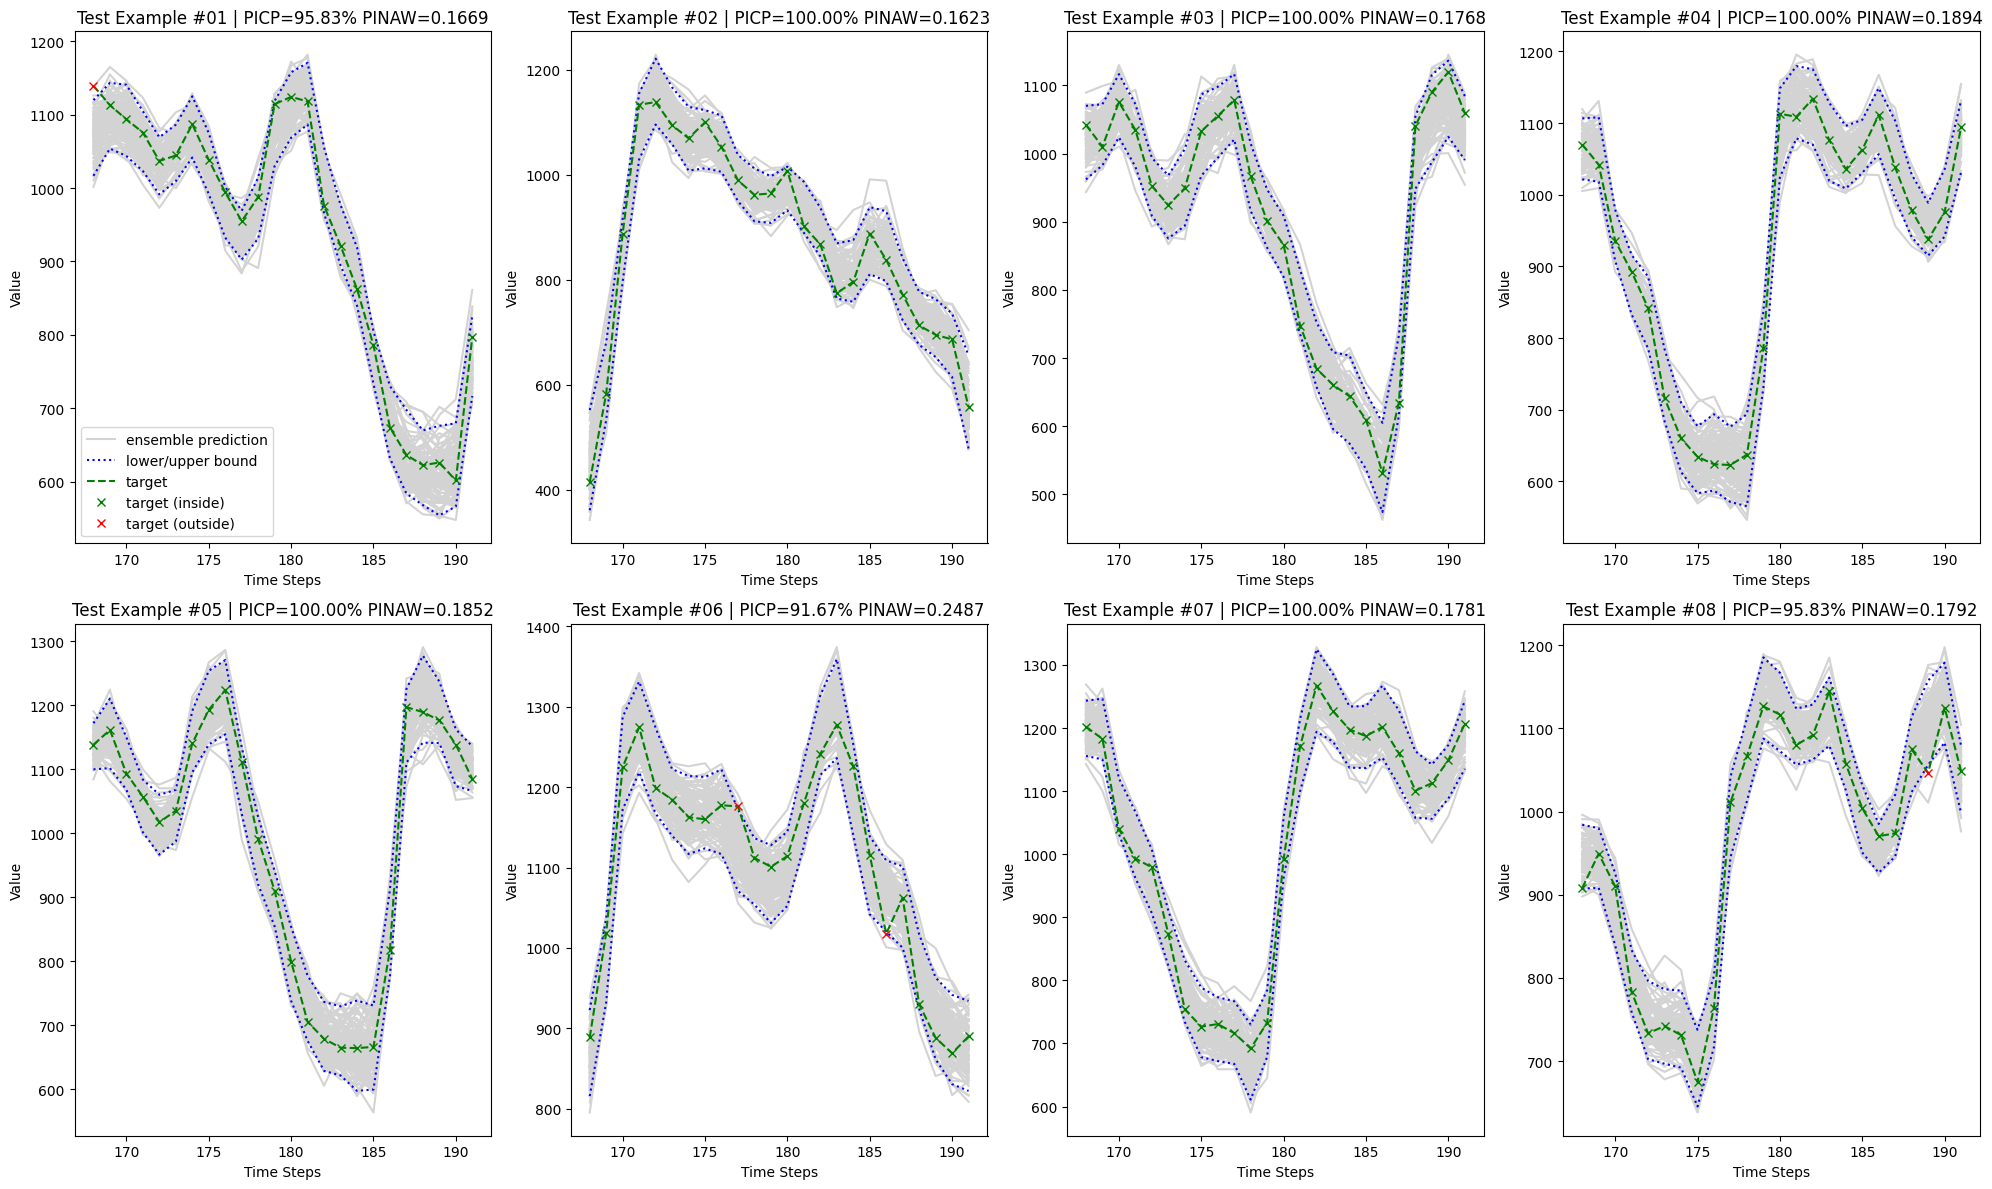

In [20]:
# Create subplots
f, axes = plt.subplots(2, 4, figsize=(20, 12))

# Create a new test loader for visualization purposes in the loop below
test_loader_batch1 = DataLoader(test_dataset, batch_size=1, shuffle=True)

for ix, ax in enumerate(axes.reshape(-1)):
    inputs, targets = next(iter(test_loader_batch1))

    # Predict
    predictions = generate_dropout_predictions(model_24hours_dropout, inputs.to(device), num_samples=100)

    # Scale back to actual values
    targets = scaler.inverse_transform(targets)
    predictions = scaler.inverse_transform(predictions.cpu().detach().squeeze().numpy())

    # Plotting ensemble predictions
    for i in range(predictions.shape[0]):
        if i == 0:
            ax.plot(np.arange(T, T+H), predictions[i,:], linestyle='-', color='lightgray', label='ensemble prediction')
        else:
            ax.plot(np.arange(T, T+H), predictions[i,:], linestyle='-', color='lightgray')

    # Plot lower and upper bounds and compute metrics
    lb, ub = calculate_prediction_intervals(torch.tensor(predictions), 95)
    ax.plot(np.arange(T, T+H), lb, linestyle=':', color='blue', label='lower/upper bound')
    ax.plot(np.arange(T, T+H), ub, linestyle=':', color='blue')

    # Plot actual targets
    ax.plot(np.arange(T, T+H), targets.squeeze(), '--g', label='target')
    for t in range(T, T+H):
        target_value = targets.squeeze()[t-T]
        if target_value < lb[t-T] or target_value > ub[t-T]:
            # Target is outside the bounds, use a different color (e.g., red)
            ax.plot(t, target_value, 'rx')  # 'rx' for red 'x'
        else:
            # Target is inside the bounds, use the standard color (e.g., green)
            ax.plot(t, target_value, 'gx')  # 'gx' for green 'x'
    # Plot dummy lines for legend
    ax.plot([], [], 'gx', label='target (inside)')
    ax.plot([], [], 'rx', label='target (outside)')

    # Compute metrics
    picp = calculate_picp(torch.tensor(targets), lb, ub)
    pinaw = calculate_pinaw(torch.tensor(targets), lb, ub)

    # Finalize plot
    ax.set_title(f'Test Example #{ix+1:02d} | PICP={picp:.2f}% PINAW={pinaw:.4f}')
    ax.set_xlabel('Time Steps')
    ax.set_ylabel('Value')
    if ix == 0:
        ax.legend()

f.tight_layout()

## Assignments

1. **Effect of dropout rate on training process and model generalization**
  - What is the effect of dropout regularization on the training process and the generalization performances of your model?
  - Try a couple of values, as well as removing dropout by setting it to 0. Discuss the results.

2. **Optimize dropout rate for probabilistic forecasting**
  - Try several dropout rates and check how the PICP and PINAW metrics change with it.
  - Ideally, you want to select the dropout rate yielding a PICP >= expected coverage (e.g., 95%) with the smallest PINAW (i.e., narrowest).
  - What is the optimal value you find?
  - Compute new test predictions by averaging the ensembles obtained with the optimal dropout. Compute the test MSE between target data and these predictions. How does it compare against the one obtained in the traditional way (e.g., point predictions).
  

# Solutions

## Assignment 1 & 2 - Testing Different Dropout Rates

We will train models with dropout rates ranging from 0 to 0.5 in 0.1 intervals and evaluate their performance to investigate the influence on performance of various dropout rates and to find the optimal one.

In [21]:
# train various gated RNNs

dropout_values = [0, 0.1, 0.2, 0.3, 0.4, 0.5]
models = []

for dropout in dropout_values:
    models.append(GatedRNN(128, 24, 'LSTM', dropout_rate=dropout).to(device))


We use arrays of models to try to do as little code duplication as possible. Feel free to put more dropout values, and rerun the notebook without any further changes to see how they perform.

In [22]:
def train(model, path):
    lr = 0.001
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    num_epochs = 1000
    return train_and_validate(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, path, echo_iter = 250)

We will train each model for 1000 epochs to benchmark consistently with our previous model. Note that this step may take a while to run, so you can lower the number of epochs for your own training!

In [23]:
train_losses = []
val_losses = []

for i, model in enumerate(models):
    tl, vl, _, _ = train(model, f'models/model_{i}.pth')
    train_losses.append(tl)
    val_losses.append(vl)

Epoch 250/1000 Train Loss: 0.0509, Validation Loss: 0.0528 Best Validation Loss: 0.0514
Epoch 500/1000 Train Loss: 0.0210, Validation Loss: 0.0228 Best Validation Loss: 0.0228
Epoch 750/1000 Train Loss: 0.0101, Validation Loss: 0.0123 Best Validation Loss: 0.0121
Epoch 1000/1000 Train Loss: 0.0071, Validation Loss: 0.0092 Best Validation Loss: 0.0088
Training complete.
Epoch 250/1000 Train Loss: 0.0358, Validation Loss: 0.0268 Best Validation Loss: 0.0268
Epoch 500/1000 Train Loss: 0.0712, Validation Loss: 0.0602 Best Validation Loss: 0.0156
Epoch 750/1000 Train Loss: 0.0268, Validation Loss: 0.0181 Best Validation Loss: 0.0156
Epoch 1000/1000 Train Loss: 0.0201, Validation Loss: 0.0121 Best Validation Loss: 0.0117
Training complete.
Epoch 250/1000 Train Loss: 0.0471, Validation Loss: 0.0294 Best Validation Loss: 0.0293
Epoch 500/1000 Train Loss: 0.0361, Validation Loss: 0.0183 Best Validation Loss: 0.0174
Epoch 750/1000 Train Loss: 0.0335, Validation Loss: 0.0145 Best Validation Loss:

With the training complete, we plot the training losses of the different models and then move on to evaluating them.

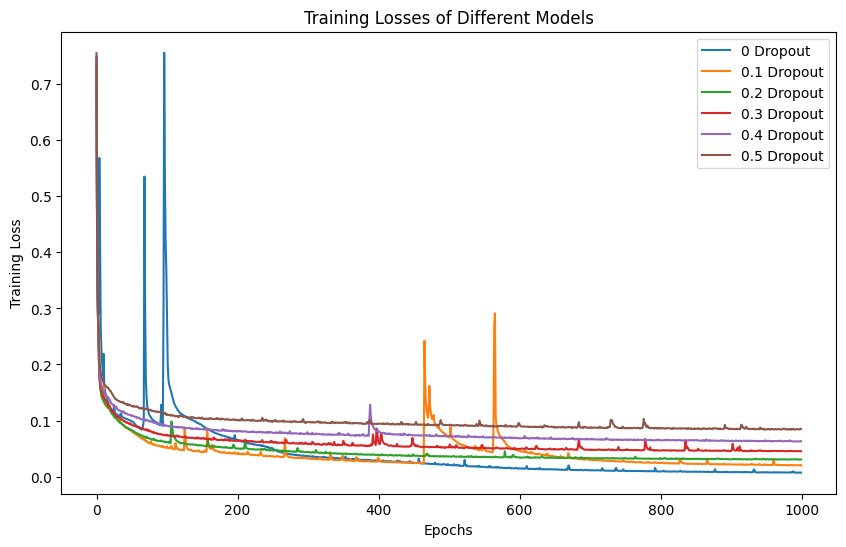

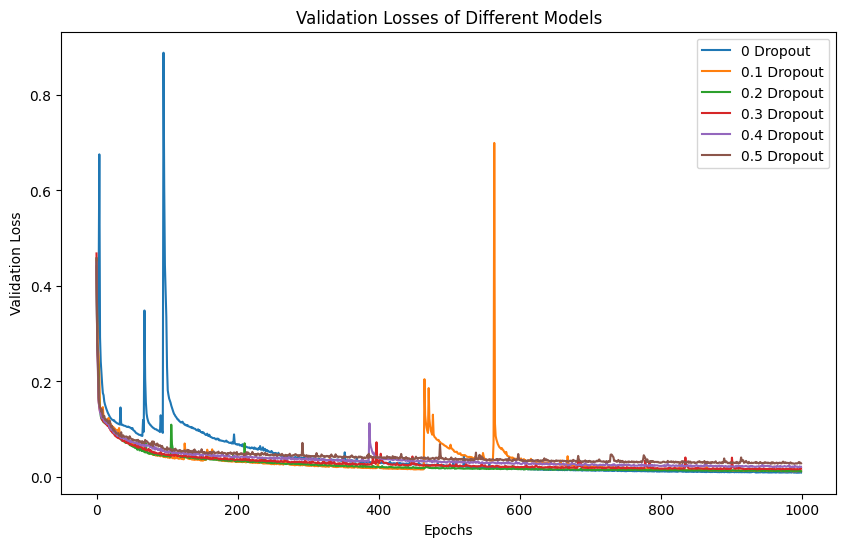

In [24]:
# Plotting training losses
plt.figure(figsize=(10, 6))
for i, train_loss in zip(dropout_values, train_losses):
    plt.plot(train_loss, label=f"{i} Dropout")

plt.title('Training Losses of Different Models')
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.legend()
plt.show()

# Plotting validation losses
plt.figure(figsize=(10, 6))
for i, val_loss in zip(dropout_values, val_losses):
    plt.plot(val_loss, label=f"{i} Dropout")

plt.title('Validation Losses of Different Models')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()
plt.show()

We will now evaluate each model. See how much higher dropout values lose to much information in our case, and these are not ideal.

In [26]:
# load best weights
for i, model in enumerate(models):
    model.load_state_dict(torch.load(f'models/model_{i}.pth', map_location=torch.device(device)))

    criterion = nn.MSELoss()  # Or another appropriate loss function
    avg_test_loss = evaluate_model(model, test_loader, criterion, device)
    print(f"GatedRNN --> num. trainable parameters:{count_parameters(model):8d} | Test loss: {avg_test_loss:.4f}")

<ipython-input-26-db798a1172c5>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'models/model_{i}.pth', map_location=torch.device(device))

GatedRNN --> num. trainable parameters:   70168 | Test loss: 0.0086
GatedRNN --> num. trainable parameters:   70168 | Test loss: 0.0114
GatedRNN --> num. trainable parameters:   70168 | Test loss: 0.0121
GatedRNN --> num. trainable parameters:   70168 | Test loss: 0.0155
GatedRNN --> num. trainable parameters:   70168 | Test loss: 0.0206
GatedRNN --> num. trainable parameters:   70168 | Test loss: 0.0276


To better compare our models, we will evaluate them with the PICP and PINAW metrics. We will look for a model with a PICP higher than 95% and the narrowest PINAW.

The following code will do so for all the different data sets, but we will focus on the test set values as those are most important and those are truly representative of whether our model is overfitting or able to generalize to new test data.

In [27]:
training_picps = []
training_pinaws = []
validation_picps = []
validation_pinaws = []
test_picps = []
test_pinaws = []

for i, model in zip(dropout_values, models):
    # Return average metrics (95% percentile) for training, validation and test
    tra_picp, tra_pinaw = compute_picp_pinaw_loader(model, train_loader, percentile=95, num_samples=100)
    val_picp, val_pinaw = compute_picp_pinaw_loader(model, val_loader, percentile=95, num_samples=100)
    tst_picp, tst_pinaw = compute_picp_pinaw_loader(model, test_loader, percentile=95, num_samples=100)

    training_picps.append(tra_picp)
    training_pinaws.append(tra_pinaw)
    validation_picps.append(val_picp)
    validation_pinaws.append(val_pinaw)
    test_picps.append(tst_picp)
    test_pinaws.append(tst_pinaw)

    print(f"Metrics for dropout of {i}:")
    print(f"Training dataset:\t PICP={tra_picp:.2f}% pinaw={tra_pinaw:.4f}")
    print(f"Validation dataset:\t PICP={val_picp:.2f}% pinaw={val_pinaw:.4f}")
    print(f"Test dataset:\t\t PICP={tst_picp:.2f}% pinaw={tst_pinaw:.4f}")

Metrics for dropout of 0:
Training dataset:	 PICP=0.00% pinaw=0.0000
Validation dataset:	 PICP=0.00% pinaw=0.0000
Test dataset:		 PICP=0.00% pinaw=0.0000
Metrics for dropout of 0.1:
Training dataset:	 PICP=91.86% pinaw=0.0726
Validation dataset:	 PICP=90.02% pinaw=0.0734
Test dataset:		 PICP=90.48% pinaw=0.0738
Metrics for dropout of 0.2:
Training dataset:	 PICP=97.52% pinaw=0.1025
Validation dataset:	 PICP=96.62% pinaw=0.1034
Test dataset:		 PICP=96.76% pinaw=0.1040
Metrics for dropout of 0.3:
Training dataset:	 PICP=98.27% pinaw=0.1291
Validation dataset:	 PICP=97.69% pinaw=0.1296
Test dataset:		 PICP=97.84% pinaw=0.1303
Metrics for dropout of 0.4:
Training dataset:	 PICP=98.37% pinaw=0.1535
Validation dataset:	 PICP=98.13% pinaw=0.1549
Test dataset:		 PICP=98.01% pinaw=0.1555
Metrics for dropout of 0.5:
Training dataset:	 PICP=98.12% pinaw=0.1756
Validation dataset:	 PICP=97.92% pinaw=0.1772
Test dataset:		 PICP=97.80% pinaw=0.1785


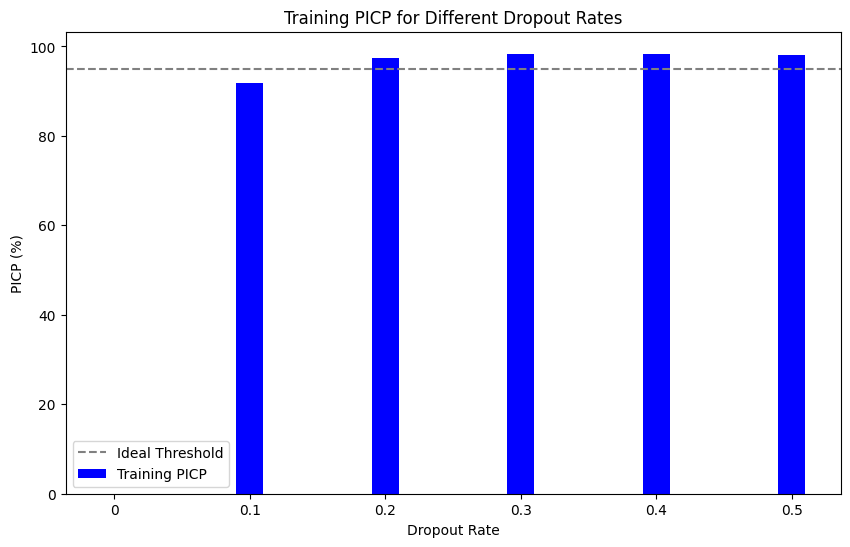

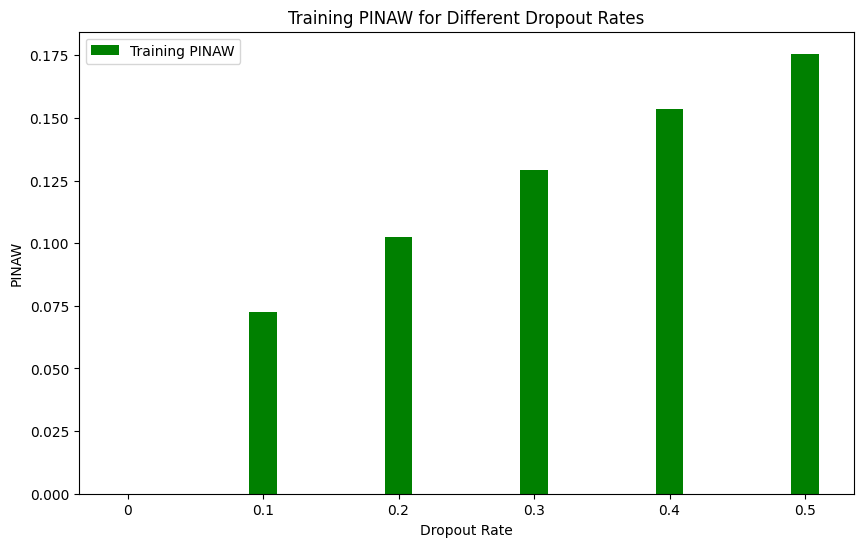

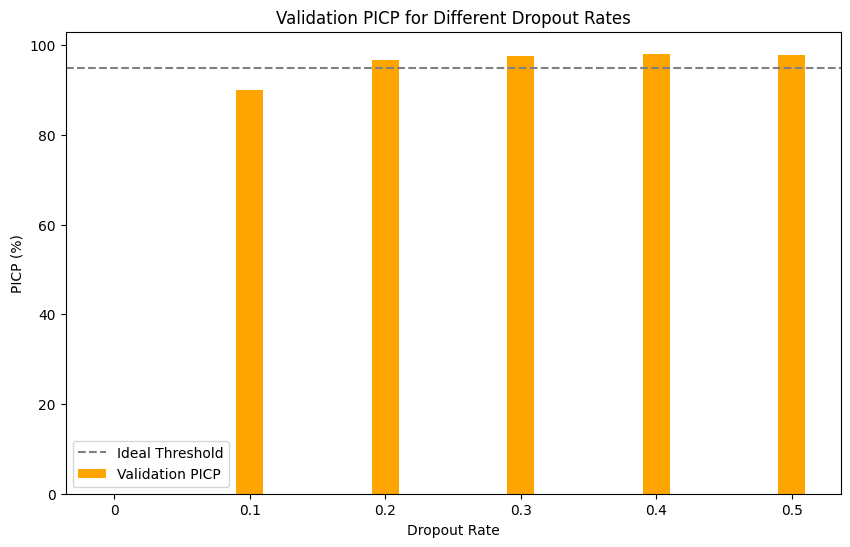

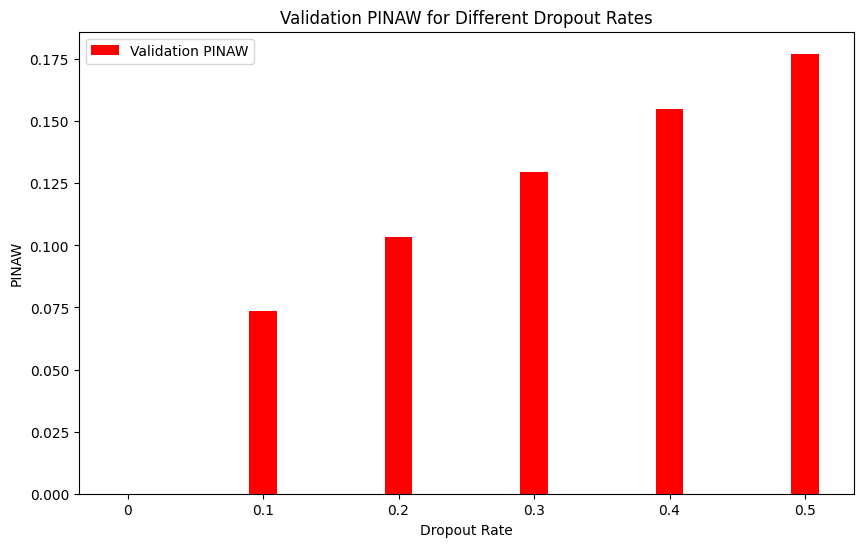

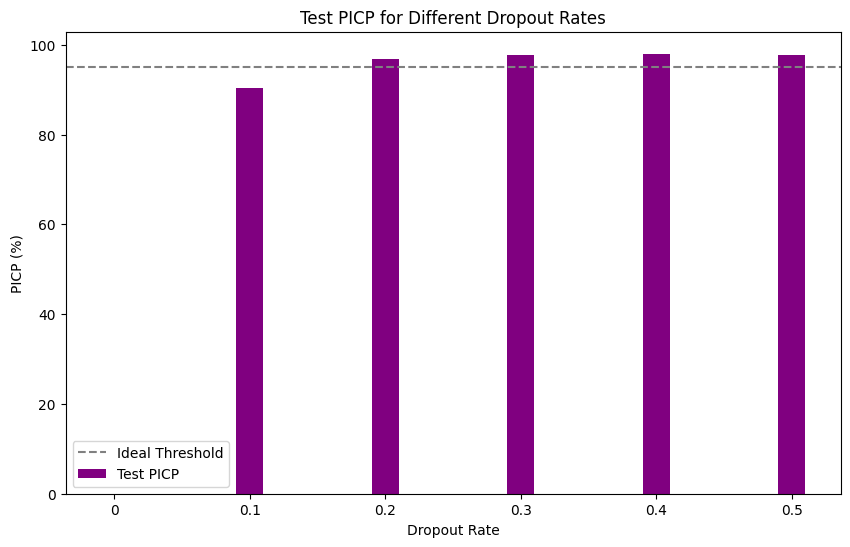

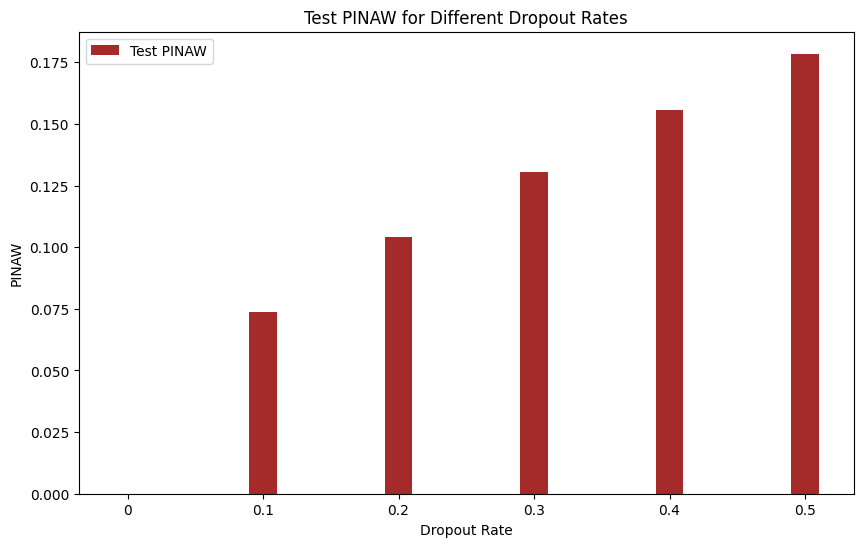

In [28]:
bar_width = 0.2
ideal_threshold = 95

# Plotting Training PICP
plt.figure(figsize=(10, 6))
plt.bar(np.arange(len(dropout_values)), training_picps, width=bar_width, color='blue', label='Training PICP')
plt.axhline(y=ideal_threshold, color='gray', linestyle='--', label='Ideal Threshold')
plt.title('Training PICP for Different Dropout Rates')
plt.xlabel('Dropout Rate')
plt.ylabel('PICP (%)')
plt.xticks(np.arange(len(dropout_values)), dropout_values)
plt.legend()
plt.show()

# Plotting Training PINAW
plt.figure(figsize=(10, 6))
plt.bar(np.arange(len(dropout_values)), training_pinaws, width=bar_width, color='green', label='Training PINAW')
plt.title('Training PINAW for Different Dropout Rates')
plt.xlabel('Dropout Rate')
plt.ylabel('PINAW')
plt.xticks(np.arange(len(dropout_values)), dropout_values)
plt.legend()
plt.show()

# Plotting Validation PICP
plt.figure(figsize=(10, 6))
plt.bar(np.arange(len(dropout_values)) + bar_width, validation_picps, width=bar_width, color='orange', label='Validation PICP')
plt.axhline(y=ideal_threshold, color='gray', linestyle='--', label='Ideal Threshold')
plt.title('Validation PICP for Different Dropout Rates')
plt.xlabel('Dropout Rate')
plt.ylabel('PICP (%)')
plt.xticks(np.arange(len(dropout_values)) + bar_width, dropout_values)
plt.legend()
plt.show()

# Plotting Validation PINAW
plt.figure(figsize=(10, 6))
plt.bar(np.arange(len(dropout_values)) + bar_width, validation_pinaws, width=bar_width, color='red', label='Validation PINAW')
plt.title('Validation PINAW for Different Dropout Rates')
plt.xlabel('Dropout Rate')
plt.ylabel('PINAW')
plt.xticks(np.arange(len(dropout_values)) + bar_width, dropout_values)
plt.legend()
plt.show()

# Plotting Test PICP
plt.figure(figsize=(10, 6))
plt.bar(np.arange(len(dropout_values)) + 2 * bar_width, test_picps, width=bar_width, color='purple', label='Test PICP')
plt.axhline(y=ideal_threshold, color='gray', linestyle='--', label='Ideal Threshold')
plt.title('Test PICP for Different Dropout Rates')
plt.xlabel('Dropout Rate')
plt.ylabel('PICP (%)')
plt.xticks(np.arange(len(dropout_values)) + 2 * bar_width, dropout_values)
plt.legend()
plt.show()

# Plotting Test PINAW
plt.figure(figsize=(10, 6))
plt.bar(np.arange(len(dropout_values)) + 2 * bar_width, test_pinaws, width=bar_width, color='brown', label='Test PINAW')
plt.title('Test PINAW for Different Dropout Rates')
plt.xlabel('Dropout Rate')
plt.ylabel('PINAW')
plt.xticks(np.arange(len(dropout_values)) + 2 * bar_width, dropout_values)
plt.legend()
plt.show()

We can conclude that a dropout rate of $0.2$ is the best of the ones we tested. This showcases the benefit of the dropout and shows how an appropriate value for the dropout rate can help us generalize to new data by not overfitting yet not losing too much information from our training data in a seemingly simple way.

We will average our ensemble predictions and plot them with comparison to the point predictions without any dropout. Pay attention to the differences in both the visualized predictions and the MSE shown in the title of each plot.

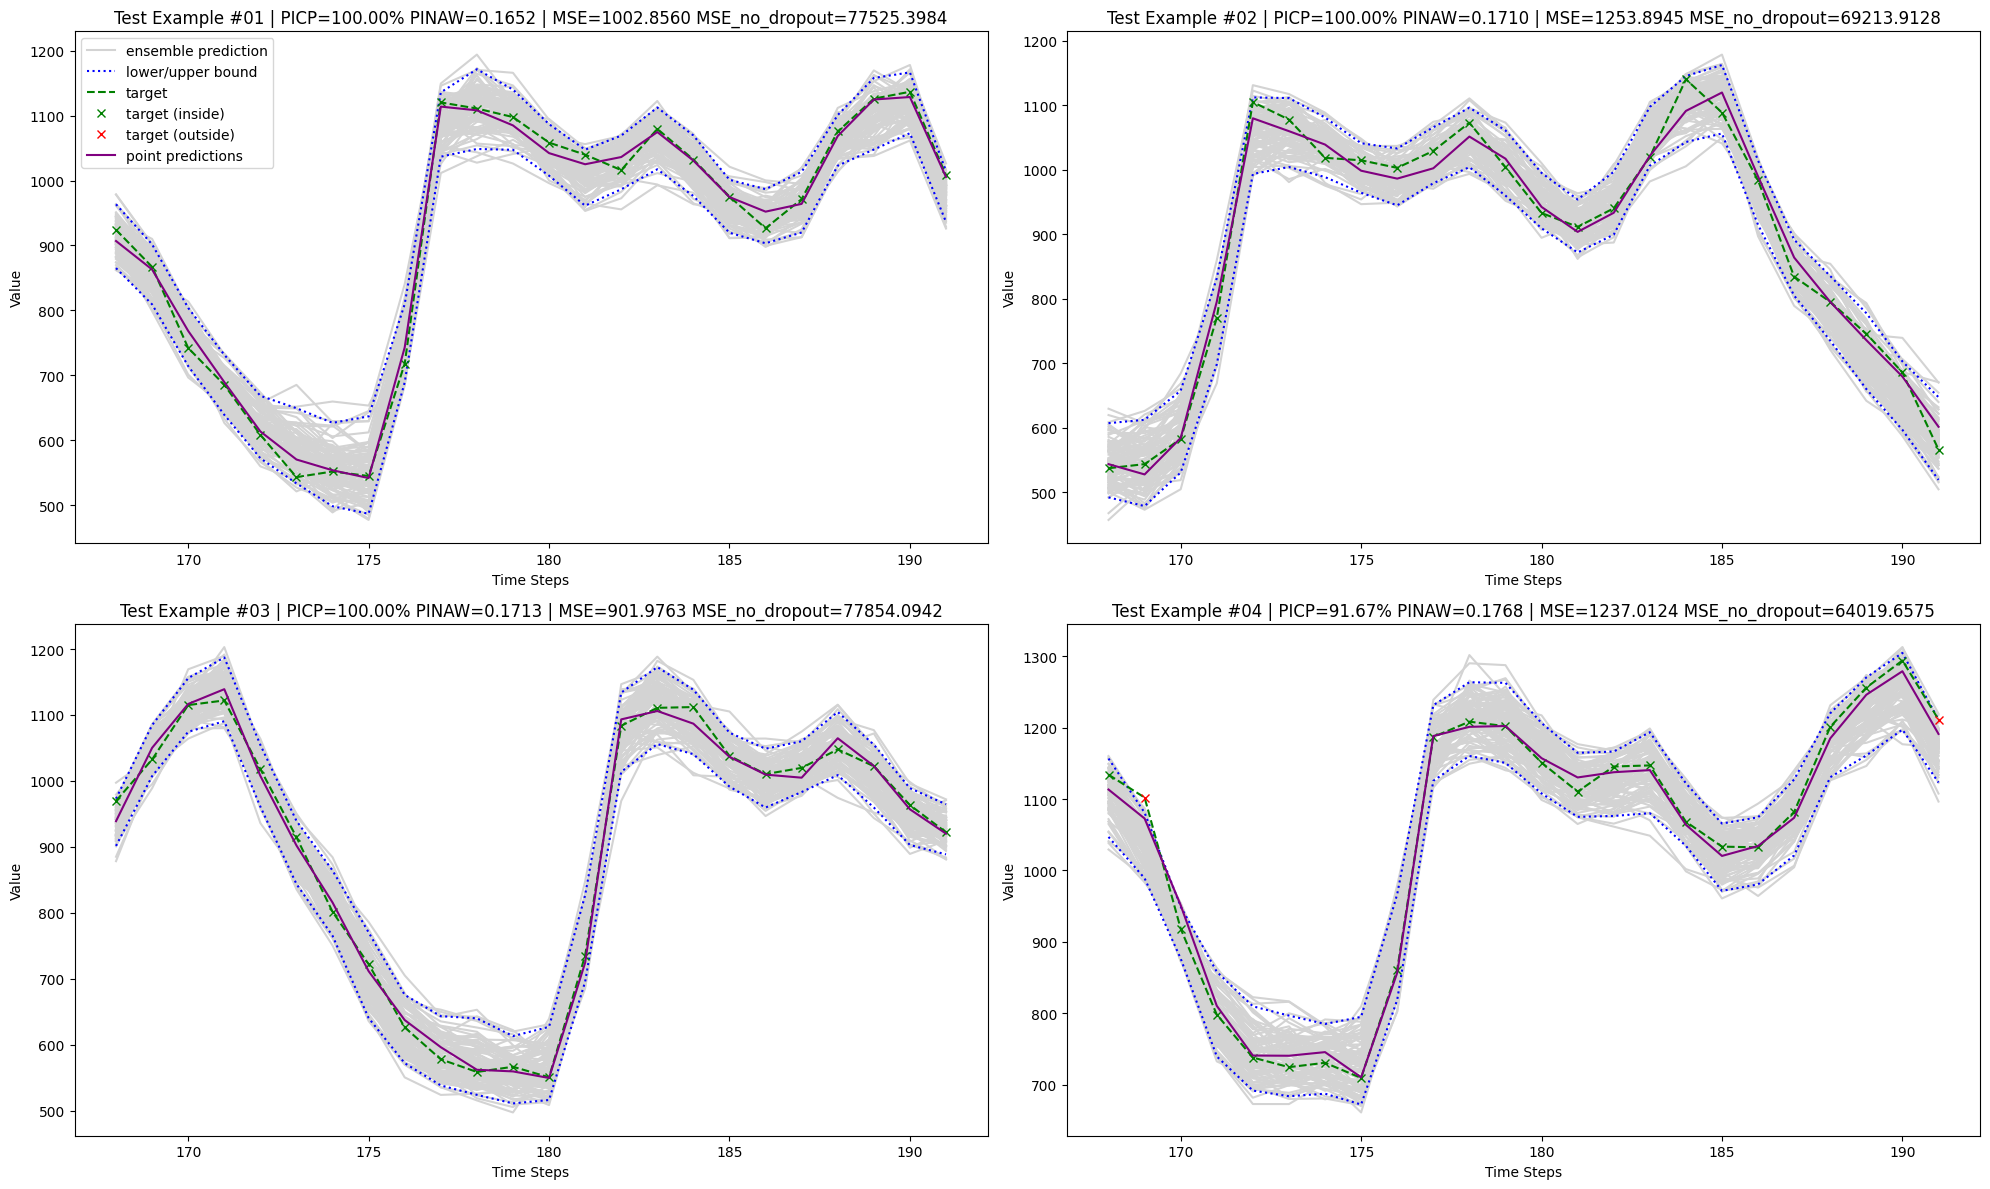

In [29]:
# Create subplots
f, axes = plt.subplots(2, 2, figsize=(20, 12))

# Create a new test loader for visualization purposes in the loop below
test_loader_batch1 = DataLoader(test_dataset, batch_size=1, shuffle=True)

for ix, ax in enumerate(axes.reshape(-1)):
    inputs, targets = next(iter(test_loader_batch1))

    # Predict
    predictions = generate_dropout_predictions(models[2], inputs.to(device), num_samples=100)

    predictions_normal = models[0](inputs.to(device))


    # Scale back to actual values
    targets = scaler.inverse_transform(targets)
    predictions = scaler.inverse_transform(predictions.cpu().detach().squeeze().numpy())
    predictions_normal = scaler.inverse_transform(predictions_normal.cpu().detach().squeeze().numpy().reshape(-1,1))

    # Plotting ensemble predictions
    for i in range(predictions.shape[0]):
        if i == 0:
            ax.plot(np.arange(T, T+H), predictions[i,:], linestyle='-', color='lightgray', label='ensemble prediction')
        else:
            ax.plot(np.arange(T, T+H), predictions[i,:], linestyle='-', color='lightgray')

    # Plot lower and upper bounds and compute metrics
    lb, ub = calculate_prediction_intervals(torch.tensor(predictions), 95)
    ax.plot(np.arange(T, T+H), lb, linestyle=':', color='blue', label='lower/upper bound')
    ax.plot(np.arange(T, T+H), ub, linestyle=':', color='blue')

    # Plot actual targets
    ax.plot(np.arange(T, T+H), targets.squeeze(), '--g', label='target')
    for t in range(T, T+H):
        target_value = targets.squeeze()[t-T]
        if target_value < lb[t-T] or target_value > ub[t-T]:
            # Target is outside the bounds, use a different color (e.g., red)
            ax.plot(t, target_value, 'rx')  # 'rx' for red 'x'
        else:
            # Target is inside the bounds, use the standard color (e.g., green)
            ax.plot(t, target_value, 'gx')  # 'gx' for green 'x'
    # Plot dummy lines for legend
    ax.plot([], [], 'gx', label='target (inside)')
    ax.plot([], [], 'rx', label='target (outside)')

    # Plot the point predictions to compare to
    ax.plot(np.arange(T, T+H), predictions_normal, color='purple', label='point predictions')

    # Calculate MSE
    mse = ((predictions - targets) ** 2).mean()
    mse_no_dropout = ((predictions_normal - targets) ** 2).mean()

    # Compute metrics
    picp = calculate_picp(torch.tensor(targets), lb, ub)
    pinaw = calculate_pinaw(torch.tensor(targets), lb, ub)

    # Finalize plot
    ax.set_title(f'Test Example #{ix+1:02d} | PICP={picp:.2f}% PINAW={pinaw:.4f} | MSE={mse:.4f} MSE_no_dropout={mse_no_dropout:.4f}')
    ax.set_xlabel('Time Steps')
    ax.set_ylabel('Value')
    if ix == 0:
        ax.legend()

f.tight_layout()